In [20]:
# IMPORT LIBRARIES

import torch
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

PROJECT_DIR = Path.cwd()

In [21]:
# CHECK DATASET

for split in ["train", "validation", "test"]:
    image_dir = PROJECT_DIR / "SunspotsYoloDataset" / split / "images"
    label_dir = PROJECT_DIR / "SunspotsYoloDataset"/ split / "labels"

    print(f"\n{split.upper()}")
    print("Images:", len(list(image_dir.glob("*.jpg"))))
    print("Labels:", len(list(label_dir.glob("*.txt"))))


TRAIN
Images: 1690
Labels: 1224

VALIDATION
Images: 380
Labels: 257

TEST
Images: 128
Labels: 108


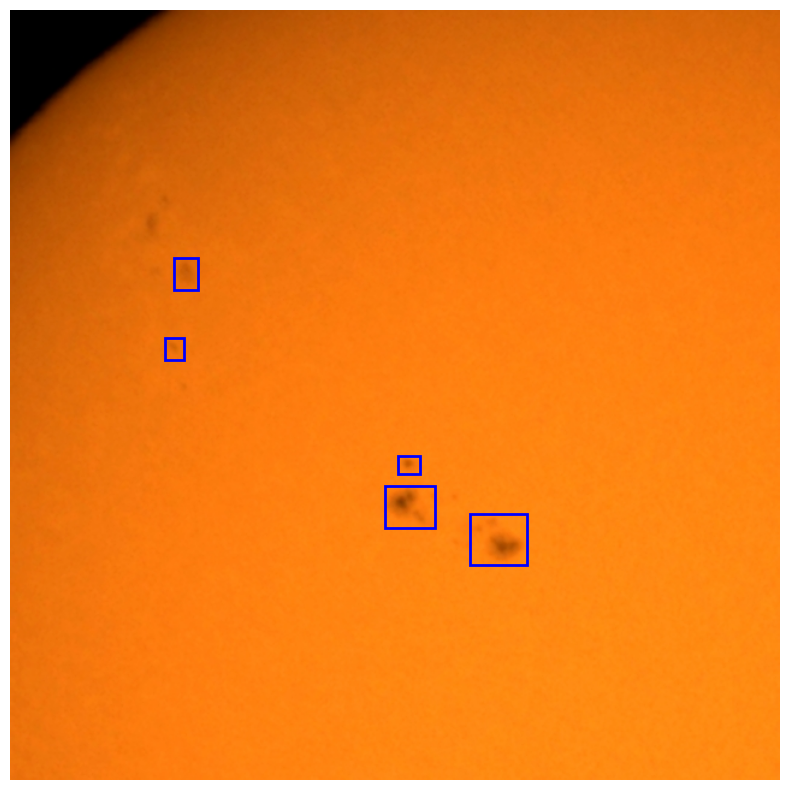

In [28]:
# CHECK ANNOTATIONS ON IMAGE

from src.dataset_utils import visualize_annotations

train_images= PROJECT_DIR / "SunspotsYoloDataset" / "train" / "images"
train_labels= PROJECT_DIR / "SunspotsYoloDataset"/ "train" / "labels"

valid_images= PROJECT_DIR / "SunspotsYoloDataset" / "valid" / "images"
valid_labels= PROJECT_DIR / "SunspotsYoloDataset"/ "valid" / "labels"

test_images= PROJECT_DIR / "SunspotsYoloDataset" / "test" / "images"
test_labels= PROJECT_DIR / "SunspotsYoloDataset"/ "test" / "labels"

image_files = sorted(train_images.glob("*.jpg"))
first_image = image_files[0]
first_label = train_labels / f"{first_image.stem}.txt"

visualize_annotations(first_image, first_label)

In [23]:
# create train dataset
from src.dataset import SunspotDataset

train_dataset= SunspotDataset(train_images, train_labels)
print(len(train_dataset))

image, target = train_dataset[0]
print(image.shape,"\n",target)

1690
torch.Size([3, 640, 640]) 
 {'boxes': tensor([[128.0000, 272.0003, 144.0000, 290.0003],
        [136.0000, 205.9997, 156.0000, 231.9997],
        [311.0000, 394.9997, 353.0000, 430.0000],
        [321.9997, 370.0000, 339.9997, 385.0003],
        [382.0000, 418.0003, 429.0003, 461.0000]]), 'labels': tensor([1, 1, 1, 1, 1])}


In [27]:
from torch.utils.data import DataLoader
from src.dataset import collate_fn

# create datasets
train_dataset= SunspotDataset(train_images, train_labels)

valid_dataset= SunspotDataset(valid_images, valid_labels)

test_dataset= SunspotDataset(test_images, test_labels)

# create dataloaders
train_loader= DataLoader(train_dataset,batch_size= 4, shuffle=True, collate_fn=collate_fn)

valid_loader= DataLoader(valid_dataset,batch_size= 4, shuffle=False, collate_fn=collate_fn)

test_loader= DataLoader(test_dataset,batch_size= 4, shuffle=False, collate_fn=collate_fn)

# test the DataLoader
images, targets = next(iter(train_loader))

print("Number of images:", len(images))
print("Number of targets:", len(targets))

print("First image shape:", images[0].shape)
print("First target:", targets[0])

Number of images: 4
Number of targets: 4
First image shape: torch.Size([3, 640, 640])
First target: {'boxes': tensor([[ 95.0000,  72.0000, 105.0000,  83.0003],
        [113.0000, 163.9997, 131.9997, 189.0000],
        [113.0000, 104.0000, 123.0000, 115.0003]]), 'labels': tensor([1, 1, 1])}


In [29]:
from src.model import create_model

model = create_model()
print(model)


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to C:\Users\MAHASHREE AJMERI/.cache\torch\hub\checkpoints\fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:04<00:00, 35.9MB/s] 


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [30]:
print(model.roi_heads.box_predictor)

FastRCNNPredictor(
  (cls_score): Linear(in_features=1024, out_features=2, bias=True)
  (bbox_pred): Linear(in_features=1024, out_features=8, bias=True)
)
